In [1]:
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt

## Boundary QA

  STATEFP COUNTYFP  COUNTYNS         GEOIDFQ  GEOID   NAME      NAMELSAD  \
0      06      007  01675842  0500000US06007  06007  Butte  Butte County   

  STUSPS  STATE_NAME LSAD       ALAND     AWATER  \
0     CA  California   06  4238488659  105260548   

                                            geometry  
0  POLYGON ((-176942.974 204861.008, -176783.151 ...  

Boundary CRS:
EPSG:3310

Number of Features:
1


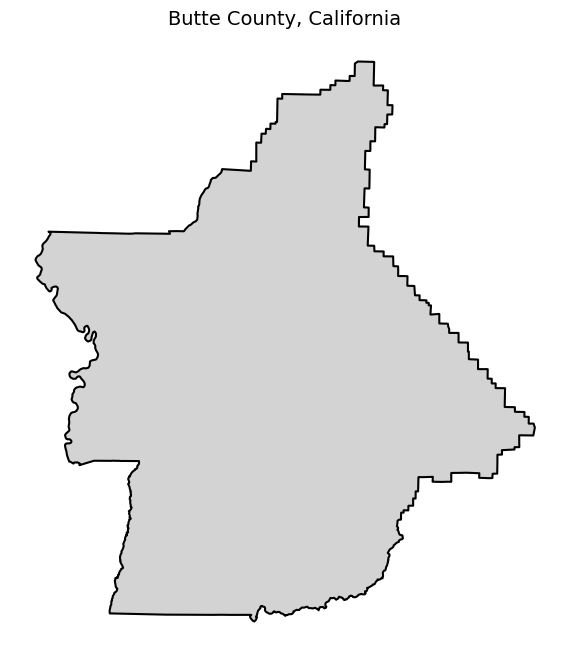

In [2]:
boundary = gpd.read_file(
    "../data/raw/boundaries/"
    "butte_county_boundary.geojson"
)

# ---------------------------------------------------------
# INSPECT DATA
# ---------------------------------------------------------

print(boundary.head())

print("\nBoundary CRS:")
print(boundary.crs)

print("\nNumber of Features:")
print(len(boundary))


# ---------------------------------------------------------
# PLOT BOUNDARY
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 8)
)

boundary.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray",
    linewidth=1.5
)

ax.set_title(
    "Butte County, California",
    fontsize=14
)

ax.set_axis_off()

plt.show()


## DEM QA


DEM Summary:
<xarray.DataArray (y: 3083, x: 3574)> Size: 88MB
[11018642 values with dtype=float64]
Coordinates:
  * y            (y) float64 25kB 40.15 40.15 40.15 40.15 ... 39.3 39.3 39.3
  * x            (x) float64 29kB -122.1 -122.1 -122.1 ... -121.1 -121.1 -121.1
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    resolution:     0.0002777777777777778
    spec:           RasterSpec(epsg=4326, bounds=(-122.06944444444444, 39.295...
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      stackstac-a0f5d9aed315284ea7923bf30d204942

DEM CRS:
EPSG:4326

DEM Shape:
(3083, 3574)


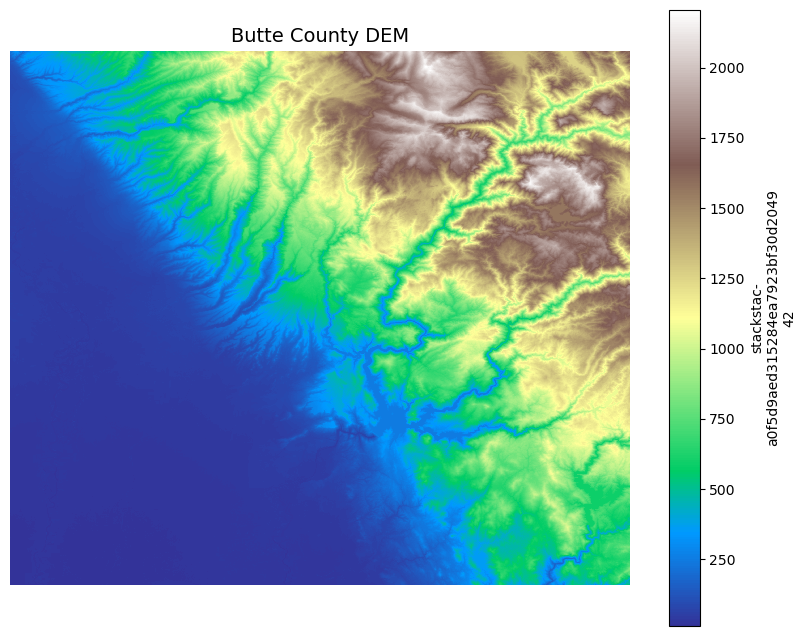

In [3]:
# LOAD DEM 
dem = rioxarray.open_rasterio(
    "../data/raw/dem/"
    "butte_county_dem.tif",
    masked=True
).squeeze()

# INSPECT DEM
print("\nDEM Summary:")
print(dem)

print("\nDEM CRS:")
print(dem.rio.crs)

print("\nDEM Shape:")
print(dem.shape)

# PLOT DEM
fig, ax = plt.subplots(
    figsize=(10, 8)
)

dem.plot(
    ax=ax,
    cmap="terrain"
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1
)

ax.set_title(
    "Butte County DEM",
    fontsize=14
)

ax.set_axis_off()

plt.show()

## QA Wildfire Perimeters


   OBJECTID  YEAR_ STATE AGENCY UNIT_ID  FIRE_NAME   INC_NUM  \
0         1   2025    CA    USF     LPF    GIFFORD  00002181   
1         2   2025    CA    USF     LPF      MADRE  00001817   
2         3   2025    CA    USF     SNF     GARNET  00001684   
3         4   2025    CA    CDF     FKU       SALT  00018739   
4         5   2025    CA    CDF     LDF  PALISADES  00000738   

                      ALARM_DATE                      CONT_DATE  CAUSE  ...  \
0  Fri, 01 Aug 2025 00:00:00 GMT  Tue, 14 Oct 2025 00:00:00 GMT     14  ...   
1  Wed, 02 Jul 2025 00:00:00 GMT  Sat, 26 Jul 2025 00:00:00 GMT     14  ...   
2  Sun, 24 Aug 2025 00:00:00 GMT  Thu, 23 Oct 2025 00:00:00 GMT      1  ...   
3  Tue, 02 Sep 2025 00:00:00 GMT  Wed, 17 Sep 2025 00:00:00 GMT      1  ...   
4  Tue, 07 Jan 2025 00:00:00 GMT  Fri, 31 Jan 2025 00:00:00 GMT     14  ...   

   OBJECTIVE  GIS_ACRES                            COMMENTS COMPLEX_NAME  \
0        1.0  131613.50                                None     

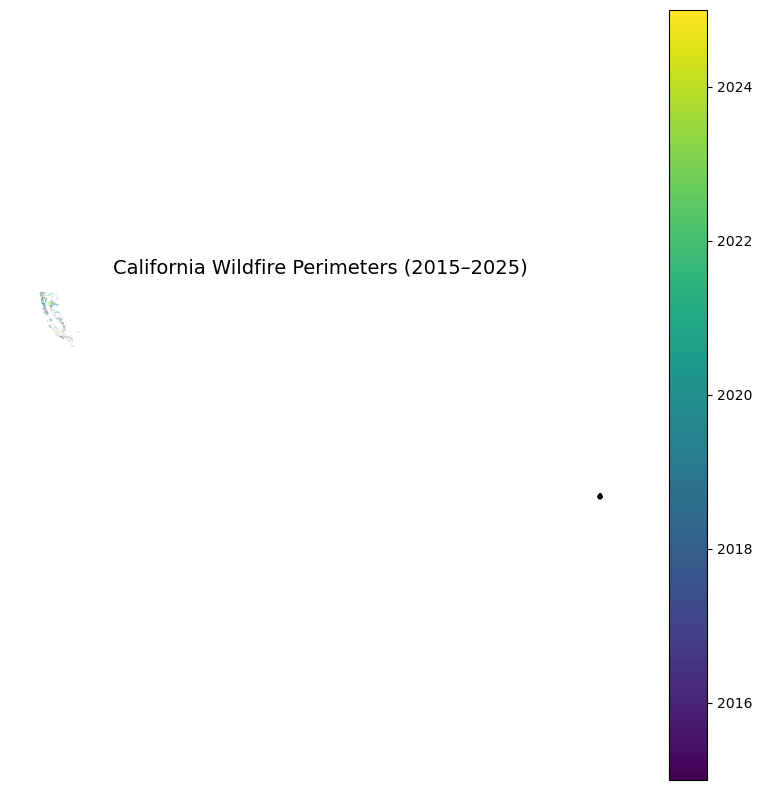

In [4]:
# ---------------------------------------------------------
# LOAD WILDFIRE DATA
# ---------------------------------------------------------

wildfire = gpd.read_file(
    "../data/raw/wildfire/"
    "butte_county_wildfire_history.geojson"
)

# ---------------------------------------------------------
# INSPECT DATA
# ---------------------------------------------------------

print(wildfire.head())

print("\nWildfire CRS:")
print(wildfire.crs)

print("\nNumber of Wildfire Records:")
print(len(wildfire))


# ---------------------------------------------------------
# PLOT WILDFIRE PERIMETERS
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

wildfire.plot(
    ax=ax,
    column="YEAR_FILTER",
    legend=True,
    alpha=0.6,
    linewidth=0.3
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.5
)

ax.set_title(
    "California Wildfire Perimeters (2015–2025)",
    fontsize=14
)

ax.set_axis_off()

plt.show()


Land Cover Summary:
<xarray.DataArray (y: 9466, x: 8477)> Size: 642MB
[80243282 values with dtype=float64]
Coordinates:
  * y            (y) float64 76kB 40.15 40.15 40.15 40.15 ... 39.3 39.3 39.3
  * x            (x) float64 68kB -122.1 -122.1 -122.1 ... -121.1 -121.1 -121.1
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    resolution_xy:  (0.00011712474135444413, 9.046788287833878e-05)
    spec:           RasterSpec(epsg=4326, bounds=(-122.06951368494605, 39.295...
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      stackstac-93e56daa417487ac3b70c9b56ff3c8bb

Land Cover CRS:
EPSG:4326

Land Cover Shape:
(9466, 8477)

Unique Land Cover Classes:
[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(11.0)]


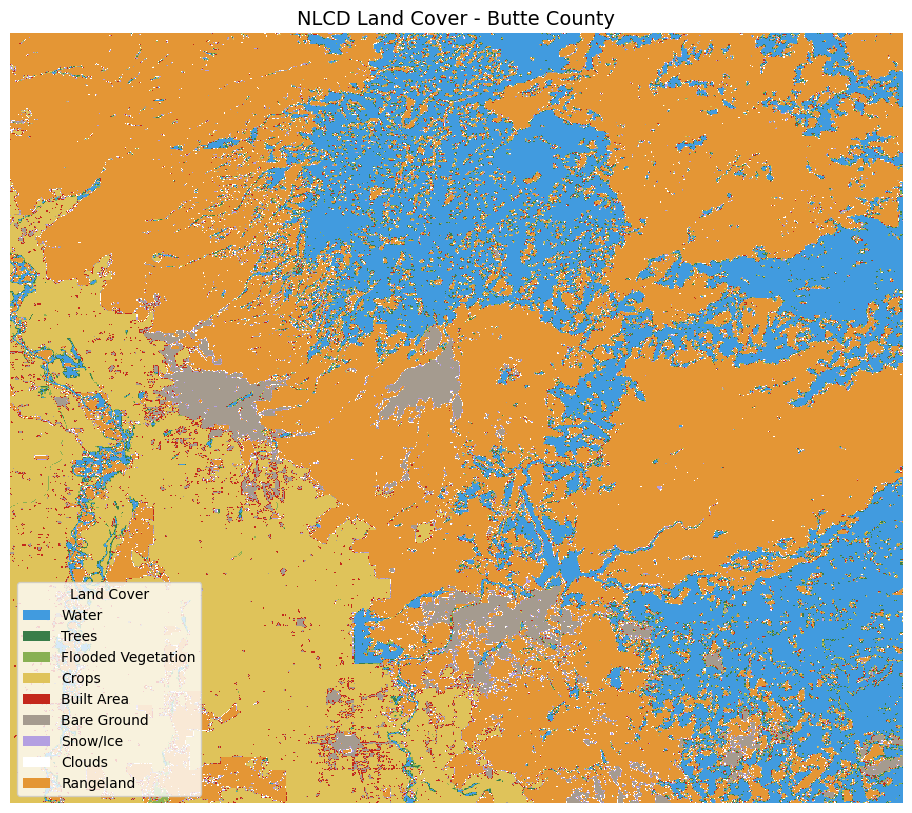

In [7]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# ---------------------------------------------------------
# LOAD LAND COVER RASTER
# ---------------------------------------------------------

landcover = rioxarray.open_rasterio(
    "../data/raw/landcover/"
    "butte_county_nlcd_landcover.tif",
    masked=True
).squeeze()


# ---------------------------------------------------------
# INSPECT RASTER
# ---------------------------------------------------------

print("\nLand Cover Summary:")
print(landcover)

print("\nLand Cover CRS:")
print(landcover.rio.crs)

print("\nLand Cover Shape:")
print(landcover.shape)

print("\nUnique Land Cover Classes:")
print(sorted(set(
    landcover.values.flatten()
)))


# ---------------------------------------------------------
# DOWNSAMPLE FOR VISUALIZATION
# ---------------------------------------------------------

landcover_preview = landcover.coarsen(
    x=10,
    y=10,
    boundary="trim"
).mean()


# ---------------------------------------------------------
# LAND COVER CLASS LABELS
# ---------------------------------------------------------

class_labels = {
    1: "Water",
    2: "Trees",
    4: "Flooded Vegetation",
    5: "Crops",
    7: "Built Area",
    8: "Bare Ground",
    9: "Snow/Ice",
    10: "Clouds",
    11: "Rangeland"
}


# ---------------------------------------------------------
# COLOR MAP
# ---------------------------------------------------------

colors = [
    "#419BDF",  # Water
    "#397D49",  # Trees
    "#88B053",  # Flooded vegetation
    "#DFC35A",  # Crops
    "#C4281B",  # Built area
    "#A59B8F",  # Bare ground
    "#B39FE1",  # Snow/Ice
    "#FFFFFF",  # Clouds
    "#E49635"   # Rangeland
]

cmap = ListedColormap(colors)


# ---------------------------------------------------------
# PLOT LAND COVER
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 10)
)

landcover_preview.plot(
    ax=ax,
    cmap=cmap,
    add_colorbar=False
)

boundary.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.5
)


# ---------------------------------------------------------
# CUSTOM LEGEND
# ---------------------------------------------------------

legend_elements = [
    Patch(
        facecolor=color,
        label=label
    )
    for color, label in zip(
        colors,
        class_labels.values()
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    title="Land Cover"
)


# ---------------------------------------------------------
# FINAL MAP SETTINGS
# ---------------------------------------------------------

ax.set_title(
    "NLCD Land Cover - Butte County",
    fontsize=14
)

ax.set_axis_off()

plt.show()